# Recommender System

#### Part I

In [1]:
import numpy as np
import pandas as pd

In [2]:
columns_names = ['user_id','item_id','rating','timestamp']

In [3]:
df = pd.read_csv('u.data', sep='\t', names=columns_names)
df.head()

,user_id,item_id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742


In [4]:
movie_titles = pd.read_csv('Movie_Id_Titles')
movie_titles.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [5]:
df = pd.merge(df,movie_titles, on ='item_id')

df.head()

,user_id,item_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)


#### Exploratory 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')
%matplotlib inline

In [9]:
df.groupby('title')['rating'].mean().sort_values(ascending=False).head()

title
Aiqing wansui (1994)                                 5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
They Made Me a Criminal (1939)                       5.0
Name: rating, dtype: float64

In [10]:
df.groupby('title')['rating'].count().sort_values(ascending=False).head()

title
Star Wars (1977)             584
Contact (1997)               509
Fargo (1996)                 508
Return of the Jedi (1983)    507
Liar Liar (1997)             485
Name: rating, dtype: int64

In [11]:
ratings = pd.DataFrame(df.groupby('title')['rating'].mean())
ratings.head()

,rating
title,
'Til There Was You (1997),2.333333
1-900 (1994),2.600000
101 Dalmatians (1996),2.908257
12 Angry Men (1957),4.344000
187 (1997),3.024390


In [12]:
ratings['Num of rating'] =  pd.DataFrame(df.groupby('title')['rating'].count())

In [13]:
ratings.head()

,rating,Num of rating
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


podemos ver en el siguiente grafico como se distribuyen un monton de peliculas que tien una sola reseña, lo que tiene sentido si son peliculas malas, por que nadie la ve y nadie opina de ellas

<Axes: >

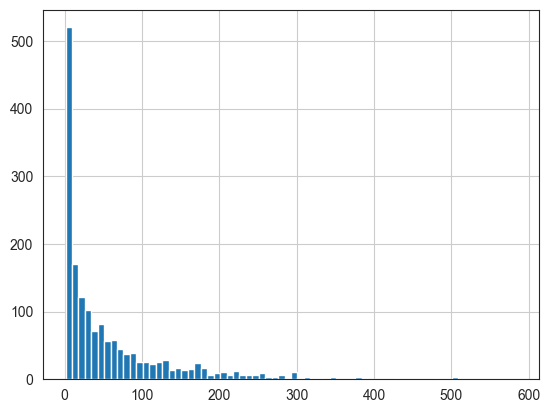

In [14]:
ratings['Num of rating'].hist(bins=70)

en el siguiente vemos como se distribuye la clasificaicon de las peliculas, y podemos observar como varias peliculas con reseña 1 igual a una estreña que son las llamadas garbage movie "Peliculas basuras", tambien vemos peliculas atipicas como son estas de 5 estrellas que la podemos identificar como esas que solo la vieron unas veces pocas y tienen estas clasificaines buenas pero que no nesesariamente lo sean, porq ue pudo tener una clasificaion de 5 estrella y solo verse 1 vez

<Axes: >

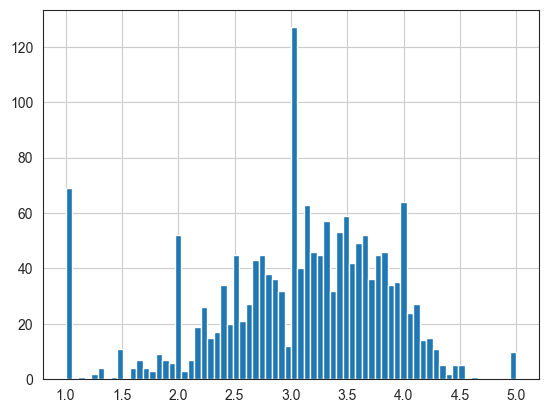

In [15]:
ratings['rating'].hist(bins=70)

aca podemos ver la relacion pudieramos decir que cuadrada de lo que comentabamos arriba, a mas reseñas mejor media de estrellas tendras debido a que fuiste una pelicula que obtuvo la atencion de muchas personas y que pudieron indicar que tan buena o mala fue la pelicula. No obstante tenemos las que tuvieron poco numero y rating de 5, que no necesariamente son buenas sino que como solo obtuvieron 1 o 2 calificaciones se quedan con esa media sesgada. 

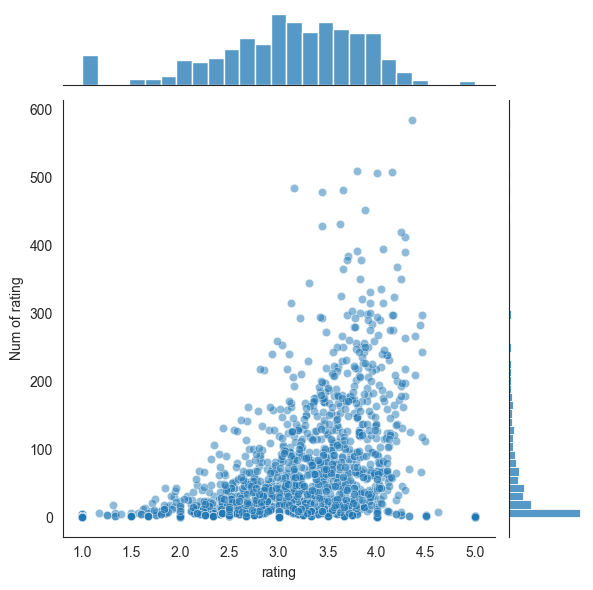

In [18]:
sns.jointplot(x='rating', y='Num of rating', data=ratings, alpha=0.5)

#### Part II 

In [19]:
df.head()

,user_id,item_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)


In [21]:
moviemat = df.pivot_table(index='user_id', columns='title', values='rating')

moviemat.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
ratings.columns

Index(['rating', 'Num of rating'], dtype='object')

In [24]:
ratings.sort_values('Num of rating', ascending=False). head()

,rating,Num of rating
title,,
Star Wars (1977),4.359589,584
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485


In [26]:
starwars_user_ratings = moviemat['Star Wars (1977)']
liarliar_user_ratings = moviemat['Liar Liar (1997)']

In [27]:
starwars_user_ratings.head()

user_id
0    5.0
1    5.0
2    5.0
3    NaN
4    5.0
Name: Star Wars (1977), dtype: float64

In [28]:
moviemat.corrwith(starwars_user_ratings)

c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


title
'Til There Was You (1997)                0.872872
1-900 (1994)                            -0.645497
101 Dalmatians (1996)                    0.211132
12 Angry Men (1957)                      0.184289
187 (1997)                               0.027398
                                           ...   
Young Guns II (1990)                     0.228615
Young Poisoner's Handbook, The (1995)   -0.007374
Zeus and Roxanne (1997)                  0.818182
unknown                                  0.723123
Á köldum klaka (Cold Fever) (1994)            NaN
Length: 1664, dtype: float64

In [29]:
similar_to_starwars = moviemat.corrwith(starwars_user_ratings)

c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [30]:
similar_to_liarliar = moviemat.corrwith(liarliar_user_ratings)

c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Erick J. Sarante\Desktop\Erick_Curso\Data_Sci_2\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [48]:
corr_starears = pd.DataFrame(similar_to_starwars, columns=['Correlation'])
corr_starears.dropna(inplace=True)
corr_starears.head()


,Correlation
title,
'Til There Was You (1997),0.872872
1-900 (1994),-0.645497
101 Dalmatians (1996),0.211132
12 Angry Men (1957),0.184289
187 (1997),0.027398


Aqui podemos ver la correlacion en base a la calificaion obtenida de starwars con otras peliculas, lo que pudiera tener sentido en base a exitos de pelicula pero que no tiene sentido cuando hablas en base a:

In [49]:
corr_starears.sort_values('Correlation', ascending=False).head()

,Correlation
title,
Star Wars (1977),1.0
Stripes (1981),1.0
Hollow Reed (1996),1.0
Man of the Year (1995),1.0
Cosi (1996),1.0


al ver la correlacion perfecta de estas peliculas podemos ver que muy probablemnte estas solo tengan una o dos calificaiones y sean 5 estrellas pero son peliculas que evidentemente no la ha visto casi nadie y estasmo diciendo que se parece a star wars cuando hablamos de calificaciones. 

Por lo que esto tenemos que arreglarlo filtrando las peliculas que tienen una cierta cantidad de calificaciones. 

<Axes: >

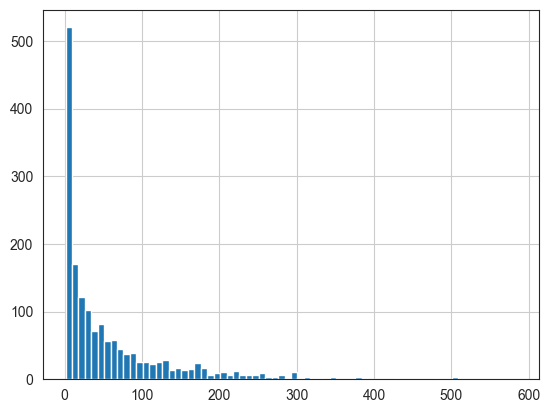

In [50]:
ratings['Num of rating'].hist(bins=70)

como vemos en este grafico seria practico filtrar por las que tienen por lo menos 100 calificaciones dabido a que aqui ya tenemos peliculas que han tenido una gran cantidad de rating y que en media podemos ver si se parecen o no a starwars

In [51]:
corr_starears = corr_starears.join(ratings['Num of rating'])
corr_starears.head()

,Correlation,Num of rating
title,,
'Til There Was You (1997),0.872872,9
1-900 (1994),-0.645497,5
101 Dalmatians (1996),0.211132,109
12 Angry Men (1957),0.184289,125
187 (1997),0.027398,41


In [52]:
corr_starears[corr_starears['Num of rating']>100].sort_values('Correlation',
                                                              ascending=False).head()

,Correlation,Num of rating
title,,
Star Wars (1977),1.000000,584
"Empire Strikes Back, The (1980)",0.748353,368
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130


Como podemos ver esto tiene mas sentido, por que estas son peliculas igual de famosas que StarWars, por lo que ahora podemos decir que tenmos un sistema que esta viendo la realidad de lo que significa ser una pelicula exitosa, tener un rating, para asi poder recomendar 

In [43]:
# Vamos con Liar liar

In [53]:
corr_liarliar = pd.DataFrame(similar_to_liarliar, columns=['Correlation'])

In [54]:
corr_liarliar

,Correlation
title,
'Til There Was You (1997),0.118913
1-900 (1994),NaN
101 Dalmatians (1996),0.469765
12 Angry Men (1957),0.066272
187 (1997),0.175145
...,...
Young Guns II (1990),0.352174
"Young Poisoner's Handbook, The (1995)",0.445016
Zeus and Roxanne (1997),-0.500000


In [55]:
corr_liarliar.dropna(inplace=True)

In [56]:
corr_liarliar = corr_liarliar.join(ratings['Num of rating'])
corr_liarliar.head()

,Correlation,Num of rating
title,,
'Til There Was You (1997),0.118913,9
101 Dalmatians (1996),0.469765,109
12 Angry Men (1957),0.066272,125
187 (1997),0.175145,41
2 Days in the Valley (1996),0.040739,93


In [57]:
corr_liarliar[corr_liarliar['Num of rating']>100].sort_values('Correlation',
                                                              ascending=False).head()

,Correlation,Num of rating
title,,
Liar Liar (1997),1.000000,485
Batman Forever (1995),0.516968,114
"Mask, The (1994)",0.484650,129
Down Periscope (1996),0.472681,101
Con Air (1997),0.469828,137
